# Exploratory Data Analysis — Online Retail Sales

## Business Objective

The goal of this analysis is to understand the sales performance of the
online retail business and identify patterns that can support business
decision-making.

The analysis focuses on:

- Overall revenue and transaction performance
- Revenue trends over time
- Best-performing products
- Customer purchasing behavior
- Country-level sales performance
- Transaction and purchasing patterns

The analysis uses the cleaned product-sales dataset created during the
data-cleaning phase.

## Key Business Questions

1. How much revenue did the business generate?
2. How does revenue change over time?
3. Which products generate the most revenue?
4. Which products sell the highest quantities?
5. Which customers contribute the most revenue?
6. Which countries generate the most sales?
7. How frequently do customers purchase?
8. Are there noticeable patterns in transaction size and purchasing behavior?
9. What business insights can be derived from these patterns?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
sales_df = pd.read_csv("../data/processed/online_retail_sales.csv")

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
sales_df.shape

(523043, 9)

In [4]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 523043 entries, 0 to 523042
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    523043 non-null  int64  
 1   StockCode    523043 non-null  str    
 2   Description  523043 non-null  str    
 3   Quantity     523043 non-null  int64  
 4   InvoiceDate  523043 non-null  str    
 5   UnitPrice    523043 non-null  float64
 6   CustomerID   391577 non-null  float64
 7   Country      523043 non-null  str    
 8   Revenue      523043 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 35.9 MB


In [5]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 523043 entries, 0 to 523042
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    523043 non-null  int64         
 1   StockCode    523043 non-null  str           
 2   Description  523043 non-null  str           
 3   Quantity     523043 non-null  int64         
 4   InvoiceDate  523043 non-null  datetime64[us]
 5   UnitPrice    523043 non-null  float64       
 6   CustomerID   391577 non-null  float64       
 7   Country      523043 non-null  str           
 8   Revenue      523043 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 35.9 MB


## 1. Overall Sales Performance

### Business Question

How large is the business in terms of revenue, transactions, quantity sold,
products, customers, and countries?

We will first calculate the main sales KPIs to establish a baseline for the
rest of the analysis.

In [6]:
total_revenue = sales_df["Revenue"].sum()
total_transactions = sales_df["InvoiceNo"].nunique()
total_quantity = sales_df["Quantity"].sum()
unique_products = sales_df["StockCode"].nunique()
unique_customers = sales_df["CustomerID"].nunique()
unique_countries = sales_df["Country"].nunique()

average_order_value = total_revenue / total_transactions

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Countries: {unique_countries:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,332,937.00
Total Transactions: 19,881
Total Quantity Sold: 5,568,561
Unique Products: 3,918
Unique Customers: 4,338
Countries: 38
Average Order Value: £519.74


### Findings

The cleaned sales dataset contains 523,043 sales line items across 19,881
unique transactions.

The business generated approximately £10.33 million in revenue and sold
5.57 million units across 3,918 unique products and 38 countries.

There are 4,338 identifiable customers in the dataset. CustomerID is missing
for some transactions, so this customer count represents only transactions
that can be linked to a known customer.

The average revenue per transaction is approximately £519.74.

### Business Interpretation

The dataset represents a large volume of product-level sales activity across
a broad international customer base.

The relatively high average transaction value compared with individual
product prices suggests that customers typically purchase multiple items
within an invoice. This will be investigated further through transaction-size
and purchasing-behavior analysis.

The overall KPIs provide a baseline for examining how revenue is distributed
over time, across products, customers, and countries.

## 2. Revenue Trend Over Time

### Business Question

How does revenue change over the analysis period?

Before examining monthly trends, we will identify the start and end dates of
the cleaned sales dataset.

In [7]:
sales_df["InvoiceDate"].min(), sales_df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

### Monthly Revenue

To understand the sales trend, revenue will be aggregated by month.

A monthly view helps identify growth patterns, seasonal changes, and unusually
strong or weak periods.

In [8]:
monthly_sales = (
    sales_df
    .set_index("InvoiceDate")
    .resample("ME")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

monthly_sales

,InvoiceDate,Revenue,Transactions,Quantity
0,2010-12-31,778810.210,1556,357744
1,2011-01-31,670751.360,1084,386787
2,2011-02-28,509318.990,1099,282721
3,2011-03-31,698828.220,1449,376292
4,2011-04-30,526023.161,1244,307771
5,2011-05-31,745708.560,1678,394692
6,2011-06-30,743161.870,1529,388185
7,2011-07-31,699910.471,1470,399407
8,2011-08-31,728020.200,1345,420740
9,2011-09-30,1035360.572,1826,569245


### Revenue Trend

The monthly revenue trend shows how sales performance changed throughout the
analysis period.

The visualization helps identify seasonal patterns, periods of growth or
decline, and unusually strong or weak months.

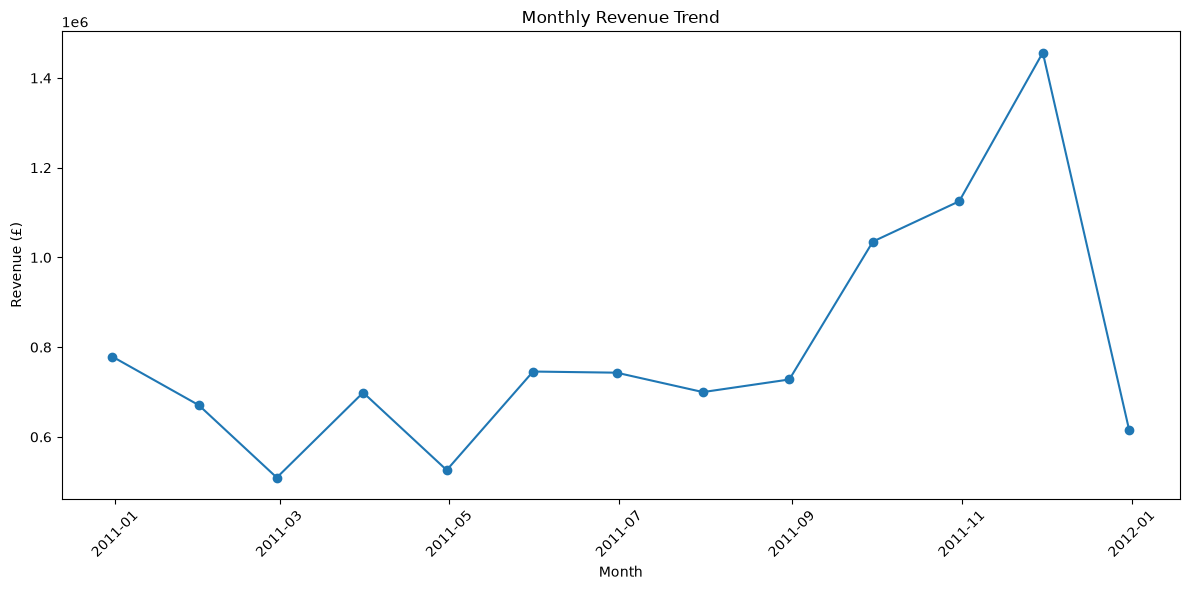

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [10]:
monthly_sales["MoM_Revenue_Change"] = monthly_sales["Revenue"].pct_change() * 100

monthly_sales[
    ["InvoiceDate", "Revenue", "MoM_Revenue_Change"]
]

,InvoiceDate,Revenue,MoM_Revenue_Change
0,2010-12-31,778810.210,NaN
1,2011-01-31,670751.360,-13.874863
2,2011-02-28,509318.990,-24.067394
3,2011-03-31,698828.220,37.208357
4,2011-04-30,526023.161,-24.727831
5,2011-05-31,745708.560,41.763446
6,2011-06-30,743161.870,-0.341513
7,2011-07-31,699910.471,-5.819916
8,2011-08-31,728020.200,4.016189
9,2011-09-30,1035360.572,42.215913


### Monthly Revenue Findings

Revenue fluctuated considerably during the first half of 2011, with notable
declines in February and April followed by strong recoveries in March and May.

From June to August, revenue was comparatively stable, remaining close to the
£700K–£750K range.

A stronger growth period began in September. Revenue increased by 42.22% in
September, followed by additional growth in October and November. November
recorded the highest monthly revenue at approximately £1.46 million.

The December 2011 value shows a 57.77% month-over-month decline, but this
should not be interpreted as a genuine decline in business performance because
the dataset only contains transactions through December 9, 2011.

Overall, the data shows substantial growth in sales activity during the final
quarter of the available period, particularly from September through November.

## 3. Product Performance

### Business Question

Which products contribute the most revenue to the business?

Understanding product-level revenue concentration can help identify the
products that contribute most to overall sales.

In [11]:
product_revenue = (
    sales_df
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

product_revenue.head(10)

,StockCode,Description,Revenue,Quantity,Transactions
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2877,47566,PARTY BUNTING,99445.23,18283,1685
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
4148,M,Manual,77750.27,6984,289
2029,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455


### Investigating High-Revenue Product Records

Before interpreting the highest-revenue products, unusually large values should
be investigated.

The initial product summary shows two records that require additional review:

- `PAPER CRAFT , LITTLE BIRDIE` has 80,995 units in a single transaction.
- `Manual` appears as a high-revenue record but does not represent a normal
  product.

These records will be investigated before drawing conclusions about product
performance.

In [12]:
sales_df[
    sales_df["StockCode"].isin(["23843", "M"])
][
    ["InvoiceNo", "StockCode", "Description", "Quantity",
     "UnitPrice", "Revenue", "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country
2156,536569,M,Manual,1,1.25,1.25,16274.0,United Kingdom
2167,536569,M,Manual,1,18.95,18.95,16274.0,United Kingdom
5490,536865,M,Manual,1,2.55,2.55,NaN,United Kingdom
6585,536981,M,Manual,2,0.85,1.70,14723.0,United Kingdom
7708,537077,M,Manual,12,0.42,5.04,17062.0,United Kingdom
...,...,...,...,...,...,...,...,...
507587,580646,M,Manual,800,0.25,200.00,17857.0,United Kingdom
512337,580884,M,Manual,1,0.85,0.85,15907.0,United Kingdom
512838,580956,M,Manual,4,1.25,5.00,17841.0,United Kingdom
519532,581405,M,Manual,3,0.42,1.26,13521.0,United Kingdom


In [13]:
special_items = (
    sales_df[sales_df["StockCode"].isin(["23843", "M"])]
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

special_items

,StockCode,Description,Revenue,Quantity,Transactions
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1,M,Manual,77750.27,6984,289


In [14]:
special_items["Revenue_Share_%"] = (
    special_items["Revenue"] / sales_df["Revenue"].sum() * 100
)

special_items

,StockCode,Description,Revenue,Quantity,Transactions,Revenue_Share_%
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1.630414
1,M,Manual,77750.27,6984,289,0.752451


### Standard Product Performance

The initial product analysis included a `Manual` stock code, which represents
manual transactions rather than a standardized product.

For product-level performance analysis, `Manual` will therefore be excluded.

The unusually large `PAPER CRAFT , LITTLE BIRDIE` transaction will be retained
because it represents an actual product sale. However, it will be highlighted
as an outlier when interpreting the results.

In [15]:
product_sales = sales_df[
    sales_df["StockCode"] != "M"
].copy()

product_revenue = (
    product_sales
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

product_revenue.head(10)

,StockCode,Description,Revenue,Quantity,Transactions
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2877,47566,PARTY BUNTING,99445.23,18283,1685
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
2029,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
3059,79321,CHILLI LIGHTS,54096.36,10302,661


### Top Products by Quantity Sold

Revenue alone does not show product demand.

A product can generate high revenue because of a higher selling price, while
another product may generate high revenue because it sells a very large number
of units.

Therefore, product quantity will be analyzed separately.

In [16]:
product_quantity = (
    product_sales
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Quantity", ascending=False)
)

product_quantity.head(10)

,StockCode,Description,Quantity,Revenue,Transactions
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
3128,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535
3619,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189
1129,22197,POPCORN HOLDER,36749,34288.67,803
448,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455
2029,23084,RABBIT NIGHT LIGHT,30739,66870.03,994
1405,22492,MINI PAINT SET VINTAGE,26633,16937.82,380


### Revenue vs Quantity

The comparison shows that high-volume products do not necessarily generate
high revenue.

To understand the difference, average revenue per unit will be calculated for
each product.

In [17]:
product_performance = (
    product_sales
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
)

product_performance["Revenue_per_Unit"] = (
    product_performance["Revenue"] /
    product_performance["Quantity"]
)

product_performance.sort_values(
    "Revenue_per_Unit",
    ascending=False
).head(10)

,StockCode,Description,Revenue,Quantity,Transactions,Revenue_per_Unit
1415,22502,PICNIC BASKET WICKER 60 PIECES,39619.50,61,2,649.500000
1741,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,5415.00,35,26,154.714286
1742,22828,REGENCY MIRROR WITH SHUTTERS,1530.00,10,7,153.000000
1568,22656,VINTAGE BLUE KITCHEN CABINET,3685.00,26,20,141.730769
1567,22655,VINTAGE RED KITCHEN CABINET,8125.00,60,38,135.416667
1737,22823,CHEST NATURAL WOOD 20 DRAWERS,2745.00,24,13,114.375000
1740,22826,LOVE SEAT ANTIQUE WHITE METAL,6210.00,58,41,107.068966
961,22016,Dotcomgiftshop Gift Voucher £100.00,83.33,1,1,83.330000
1844,22929,SCHOOL DESK AND CHAIR,1199.75,19,13,63.144737
3277,84632,DECORATIVE HANGING SHELVING UNIT,359.70,6,5,59.950000


### Product Performance Comparison

Revenue, quantity, and transaction frequency provide different views of
product performance.

Revenue measures financial contribution, quantity measures sales volume, and
transactions indicate how frequently a product appears across customer
orders.

The following analysis focuses on the highest-revenue products and compares
their sales volume and transaction frequency.

In [18]:
top_products = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(20)
)

top_products[
    ["Description", "Revenue", "Quantity", "Transactions"]
]

,Description,Revenue,Quantity,Transactions
1340,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2668,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3640,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2877,PARTY BUNTING,99445.23,18283,1685
3619,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2123,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
2029,RABBIT NIGHT LIGHT,66870.03,30739,994
1022,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
3416,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
3059,CHILLI LIGHTS,54096.36,10302,661


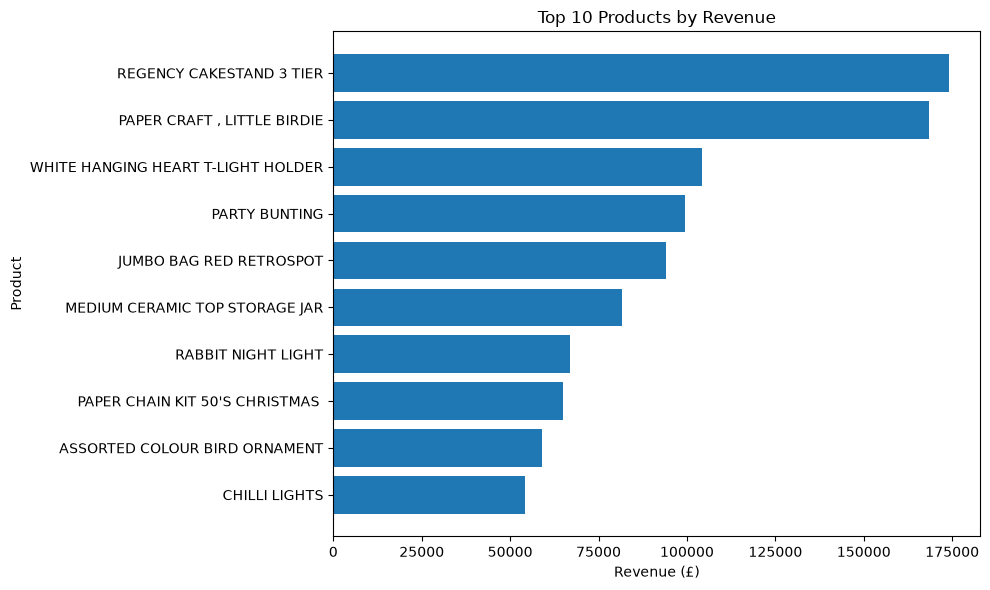

In [19]:
top_10_products = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products["Description"],
    top_10_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Product Revenue Findings

The top revenue-generating product is `REGENCY CAKESTAND 3 TIER`, with
approximately £174K in revenue.

`PAPER CRAFT, LITTLE BIRDIE` ranks second with approximately £168K.
However, this result is driven by a single transaction containing 80,995
units, which was identified earlier as an unusual but valid transaction.
Therefore, its ranking should be interpreted separately from products with
repeated sales activity.

Several products show stronger evidence of consistent demand. For example,
`WHITE HANGING HEART T-LIGHT HOLDER`, `PARTY BUNTING`, and
`JUMBO BAG RED RETROSPOT` generate high revenue across hundreds or thousands
of transactions.

This shows why product performance should be evaluated using multiple
measures rather than revenue alone. Revenue, quantity sold, and transaction
frequency provide different perspectives on product performance.

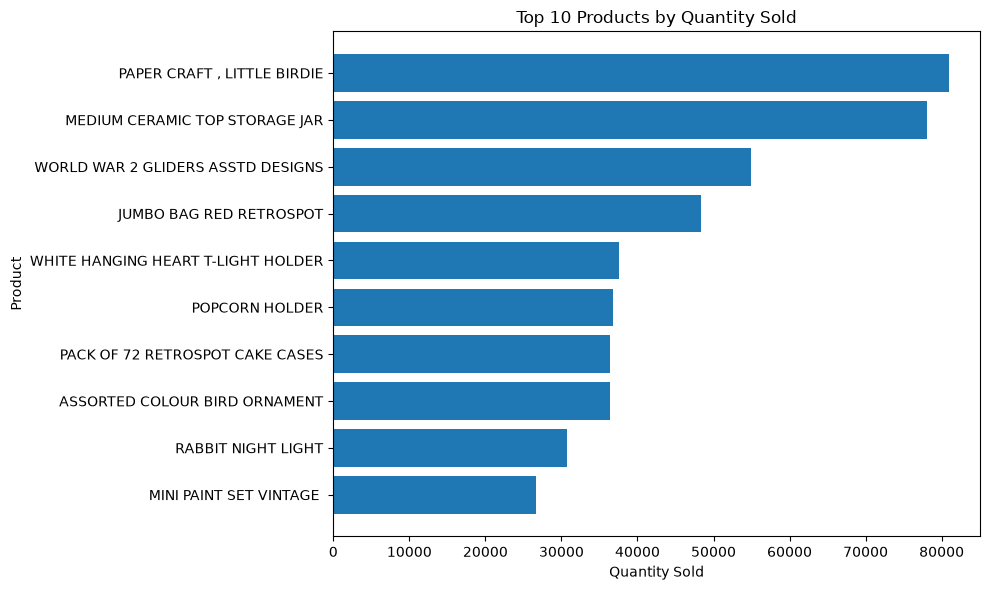

In [20]:
top_10_quantity = (
    product_quantity
    .sort_values("Quantity", ascending=False)
    .head(10)
    .sort_values("Quantity")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_quantity["Description"],
    top_10_quantity["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Quantity Performance Findings

The quantity analysis shows that high sales volume does not necessarily
translate into high revenue.

`PAPER CRAFT, LITTLE BIRDIE` has the highest recorded quantity at 80,995
units, but this is driven by a single transaction and should therefore be
treated as an outlier.

`MEDIUM CERAMIC TOP STORAGE JAR` is another high-volume product, with 78,033
units sold across 247 transactions and approximately £81.7K in revenue.

`WORLD WAR 2 GLIDERS ASSTD DESIGNS` sold approximately 55K units but generated
only about £13.8K in revenue. This indicates that its lower selling price
allows high unit volume without producing proportionally high revenue.

Products such as `JUMBO BAG RED RETROSPOT` and `WHITE HANGING HEART T-LIGHT
HOLDER` perform strongly on both quantity and revenue, indicating more
balanced commercial performance.

Overall, quantity sold and revenue measure different aspects of product
performance. Both should be considered when evaluating products.

In [21]:
top_10_revenue = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)["Revenue"]
    .sum()
)

total_product_revenue = product_performance["Revenue"].sum()

top_10_revenue_share = (
    top_10_revenue / total_product_revenue * 100
)

print(f"Top 10 Product Revenue: £{top_10_revenue:,.2f}")
print(f"Total Product Revenue: £{total_product_revenue:,.2f}")
print(f"Top 10 Revenue Share: {top_10_revenue_share:.2f}%")

Top 10 Product Revenue: £966,985.94
Total Product Revenue: £10,255,186.73
Top 10 Revenue Share: 9.43%


### Overall Product Performance Findings

The product analysis shows that revenue is distributed across a broad range
of products rather than being concentrated in a small number of items.

The top 10 products generated approximately £966.99K, representing 9.43% of
the total product revenue of approximately £10.26 million.

Revenue and quantity rankings show different patterns. Some products generate
high revenue through relatively frequent purchases, while others achieve high
unit volumes because of lower selling prices.

Several products, including `JUMBO BAG RED RETROSPOT` and
`WHITE HANGING HEART T-LIGHT HOLDER`, perform strongly across revenue,
quantity, and transaction frequency.

Two unusual products require special interpretation. `PAPER CRAFT, LITTLE
BIRDIE` generated approximately £168K from a single transaction containing
80,995 units, while `PICNIC BASKET WICKER 60 PIECES` generated approximately
£39.6K from only two transactions. These records were retained because they
are valid source transactions, but they should not be interpreted as evidence
of consistently high customer demand.

Overall, product performance should be evaluated using multiple measures:
revenue contribution, quantity sold, and transaction frequency. Using only
one metric can produce a misleading view of product performance.

## 4. Customer Analysis

### Business Question

Who are the customers generating revenue, and how frequently do they
purchase?

Customer-level analysis can help identify high-value customers, purchasing
frequency, and differences between one-time and repeat customers.

Because some sales transactions do not have a CustomerID, customer-level
analysis will use only transactions with a known CustomerID.

In [22]:
customer_sales = sales_df.dropna(subset=["CustomerID"]).copy()

customer_sales["CustomerID"] = customer_sales["CustomerID"].astype(int)

customer_sales.shape

(391577, 9)

In [23]:
customer_summary = (
    customer_sales
    .groupby("CustomerID")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_summary["Average_Order_Value"] = (
    customer_summary["Revenue"] /
    customer_summary["Transactions"]
)

customer_summary.head()

,CustomerID,Revenue,Transactions,Quantity,Average_Order_Value
0,12346,77183.60,1,74215,77183.600000
1,12347,4310.00,7,2458,615.714286
2,12348,1437.24,4,2332,359.310000
3,12349,1457.55,1,630,1457.550000
4,12350,294.40,1,196,294.400000


In [24]:
top_customers = (
    customer_summary
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_customers

,CustomerID,Revenue,Transactions,Quantity,Average_Order_Value
1689,14646,279138.02,72,196844,3876.916944
4201,18102,259657.30,60,64124,4327.621667
3728,17450,194390.79,46,69973,4225.886739
3008,16446,168472.50,2,80997,84236.250000
1879,14911,143711.17,201,80240,714.980945
55,12415,124564.53,20,77373,6228.226500
1333,14156,117210.08,55,57768,2131.092364
3771,17511,91062.38,31,64549,2937.496129
0,12346,77183.60,1,74215,77183.600000
2702,16029,72708.09,62,40107,1172.711129


### Top Customer Findings

Customer revenue varies substantially in both value and purchasing frequency.

Customer `14646` generated the highest recorded customer revenue at
approximately £279K across 72 transactions. Customers `18102` and `17450`
also generated high revenue across 60 and 46 transactions respectively,
indicating repeated purchasing activity.

Customer `14911` generated approximately £144K across 201 transactions,
showing a particularly high purchase frequency.

However, some high customer-revenue values are driven by unusual bulk
transactions. Customer `16446` generated approximately £168K from only two
transactions and purchased 80,997 units. This customer is associated with
the previously identified `PAPER CRAFT, LITTLE BIRDIE` outlier.

Customer `12346` generated approximately £77K from a single transaction and
also purchased more than 74K units. This customer should therefore be
investigated separately before interpreting the revenue as evidence of
typical high-value customer behavior.

This demonstrates that customer revenue should be evaluated together with
transaction frequency and purchasing volume rather than revenue alone.

In [25]:
customer_frequency = (
    customer_summary
    .groupby("Transactions")
    .size()
    .reset_index(name="Customers")
)

customer_frequency.head(20)

,Transactions,Customers
0,1,1501
1,2,831
2,3,506
3,4,393
4,5,239
5,6,172
6,7,140
7,8,98
8,9,68
9,10,54


In [26]:
one_time_customers = (
    customer_summary["Transactions"] == 1
).sum()

repeat_customers = (
    customer_summary["Transactions"] > 1
).sum()

total_customers = customer_summary["CustomerID"].nunique()

one_time_pct = one_time_customers / total_customers * 100
repeat_pct = repeat_customers / total_customers * 100

print(f"Total Customers: {total_customers:,}")
print(f"One-Time Customers: {one_time_customers:,} ({one_time_pct:.2f}%)")
print(f"Repeat Customers: {repeat_customers:,} ({repeat_pct:.2f}%)")

Total Customers: 4,338
One-Time Customers: 1,501 (34.60%)
Repeat Customers: 2,837 (65.40%)


### Customer Purchase Frequency Findings

Among the 4,338 customers with an identifiable CustomerID, 1,501 customers
(34.60%) made only one transaction, while 2,837 customers (65.40%) made
multiple transactions during the available period.

This indicates that repeat purchasing is common within the identifiable
customer base.

However, this analysis describes transaction frequency within the dataset
period. It should not be interpreted as a formal customer retention or
churn rate because the dataset covers only a limited period and does not
provide information about customers before or after the observed period.

In [27]:
customer_summary["Customer_Type"] = np.where(
    customer_summary["Transactions"] == 1,
    "One-Time",
    "Repeat"
)

customer_type_summary = (
    customer_summary
    .groupby("Customer_Type")
    .agg(
        Customers=("CustomerID", "count"),
        Revenue=("Revenue", "sum"),
        Transactions=("Transactions", "sum")
    )
    .reset_index()
)

customer_type_summary["Revenue_Share_%"] = (
    customer_type_summary["Revenue"] /
    customer_summary["Revenue"].sum() * 100
)

customer_type_summary

,Customer_Type,Customers,Revenue,Transactions,Revenue_Share_%
0,One-Time,1501,621715.911,1501,7.066962
1,Repeat,2837,8175782.663,16979,92.933038


### One-Time vs Repeat Customer Revenue

The revenue contribution differs substantially between one-time and repeat
customers.

One-time customers represent 34.60% of identifiable customers but contribute
only 7.07% of customer-linked revenue.

Repeat customers represent 65.40% of identifiable customers and contribute
92.93% of customer-linked revenue.

This shows that customer frequency is strongly associated with revenue
contribution in this dataset. Repeat customers generate substantially more
revenue than one-time customers.

This comparison is based only on transactions with a known CustomerID and
should not be interpreted as a causal relationship. It also reflects
purchasing behavior during the available dataset period rather than a formal
customer lifetime value or retention analysis.

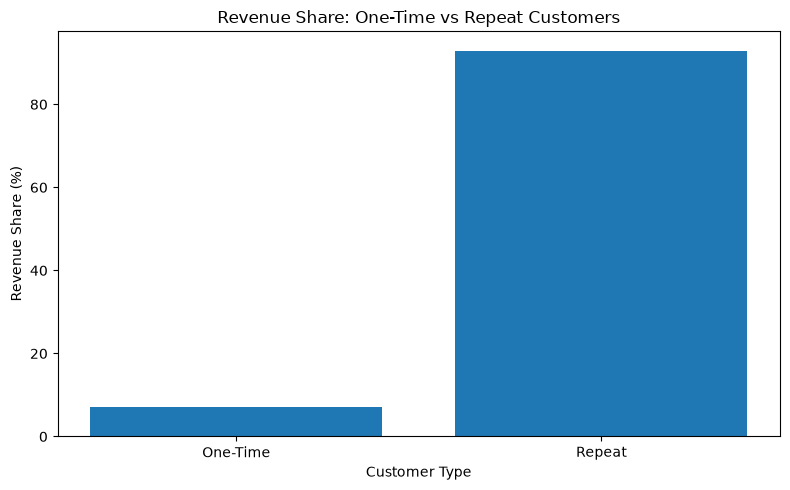

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_summary["Customer_Type"],
    customer_type_summary["Revenue_Share_%"]
)

plt.title("Revenue Share: One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Revenue Share (%)")

plt.tight_layout()
plt.show()

### Customer Revenue Findings

The revenue-share analysis shows a substantial difference between one-time and
repeat customers.

Repeat customers account for 65.40% of identifiable customers but contribute
92.93% of customer-linked revenue. One-time customers represent 34.60% of
customers but contribute only 7.07% of customer-linked revenue.

This indicates that repeat purchasing is an important component of revenue
generation within the identifiable customer base.

The result is based only on transactions with a known CustomerID and covers
the observed dataset period. It should not be interpreted as a formal
retention, churn, or customer lifetime value measure.

## 5. Country Analysis

### Business Question

Which countries generate the most revenue and sales volume?

Country-level analysis helps understand the geographic distribution of the
business and identify markets that contribute substantially to sales.

Revenue and quantity will be analyzed separately because high sales volume
does not necessarily result in proportionally high revenue.

In [29]:
country_summary = (
    sales_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

country_summary.head(10)

,Country,Revenue,Quantity,Transactions,Customers
36,United Kingdom,8761765.234,4646131,17976,3920
24,Netherlands,283889.340,200258,93,9
10,EIRE,283140.520,147007,288,3
14,Germany,207677.400,118040,449,94
13,France,194171.370,111235,387,87
0,Australia,138103.810,83890,56,9
31,Spain,55706.560,27724,88,30
33,Switzerland,53065.600,30515,50,21
20,Japan,37416.370,26016,19,8
3,Belgium,36927.340,22962,98,25


In [30]:
uk_revenue = country_summary.loc[
    country_summary["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

total_revenue = sales_df["Revenue"].sum()

uk_revenue_share = uk_revenue / total_revenue * 100

print(f"UK Revenue: £{uk_revenue:,.2f}")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"UK Revenue Share: {uk_revenue_share:.2f}%")

UK Revenue: £8,761,765.23
Total Revenue: £10,332,937.00
UK Revenue Share: 84.79%


### Geographic Revenue Concentration

The United Kingdom generated approximately £8.76 million in revenue,
representing 84.79% of total revenue in the cleaned sales dataset.

The remaining 37 countries collectively contributed approximately 15.21% of
revenue.

This indicates that the recorded sales are highly concentrated in the UK
market, while international markets account for a smaller share of total
revenue.

The result describes the geographic distribution of sales in this dataset
and does not by itself indicate whether the concentration is desirable or
undesirable for the business.

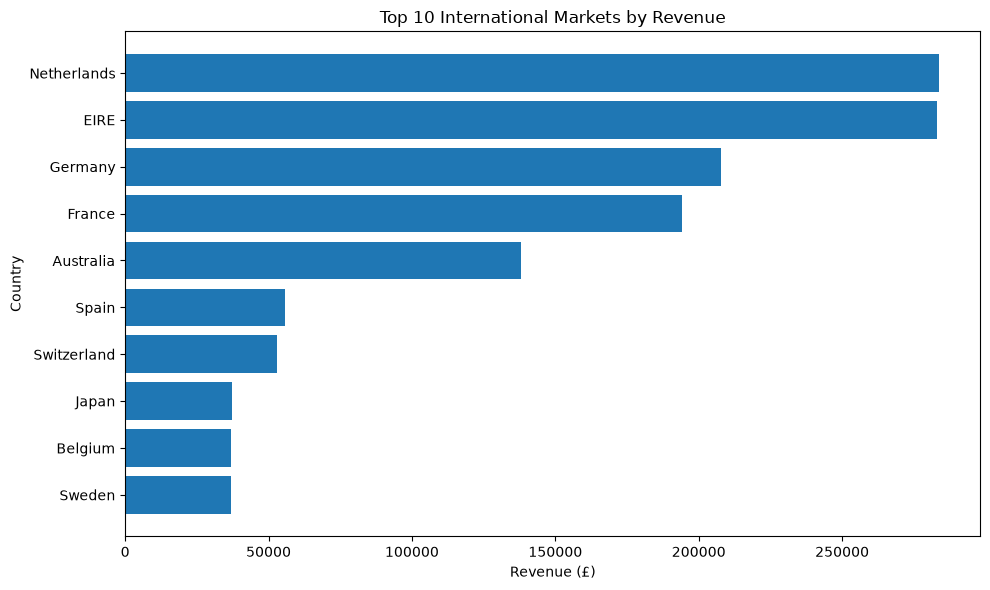

In [31]:
top_international = (
    country_summary[
        country_summary["Country"] != "United Kingdom"
    ]
    .sort_values("Revenue", ascending=False)
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_international["Country"],
    top_international["Revenue"]
)

plt.title("Top 10 International Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### International Market Findings

After excluding the United Kingdom to make the smaller markets easier to
compare, the Netherlands and EIRE recorded the highest international revenue,
at approximately £284K each.

Germany and France followed with approximately £208K and £194K respectively,
while Australia generated approximately £138K.

The international revenue distribution is considerably smaller than the UK
market, which accounts for 84.79% of total recorded revenue.

These figures describe the sales distribution in the available dataset and
should not be interpreted as a measure of market potential or future growth.

## 6. Transaction and Order Behavior

### Business Question

What does a typical customer order look like?

Order-level analysis helps understand transaction size, purchasing volume, and
the difference between typical and unusually large orders.

The analysis will examine revenue and quantity at the invoice level.

In [32]:
order_summary = (
    sales_df
    .groupby("InvoiceNo")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        LineItems=("StockCode", "count"),
        CustomerID=("CustomerID", "first"),
        Country=("Country", "first")
    )
    .reset_index()
)

order_summary.head()

,InvoiceNo,Revenue,Quantity,LineItems,CustomerID,Country
0,536365,139.12,40,7,17850.0,United Kingdom
1,536366,22.20,12,2,17850.0,United Kingdom
2,536367,278.73,83,12,13047.0,United Kingdom
3,536368,70.05,15,4,13047.0,United Kingdom
4,536369,17.85,3,1,13047.0,United Kingdom


In [33]:
order_summary["Revenue"].describe()

count     19881.000000
mean        519.739299
std        1761.467741
min           0.380000
25%         151.500000
50%         302.400000
75%         483.300000
max      168469.600000
Name: Revenue, dtype: float64

### Order Value Findings

The average order value is approximately £519.74, while the median order value
is £302.40.

The difference between the mean and median indicates that the order-value
distribution is strongly right-skewed. Most orders are substantially smaller
than the average, while a small number of unusually large orders increase the
mean.

The middle 50% of orders fall between £151.50 and £483.30.

The maximum order value is £168,469.60 and corresponds to the previously
identified unusual `PAPER CRAFT, LITTLE BIRDIE` transaction.

Therefore, the median provides a more representative measure of a typical
order than the mean for this dataset.

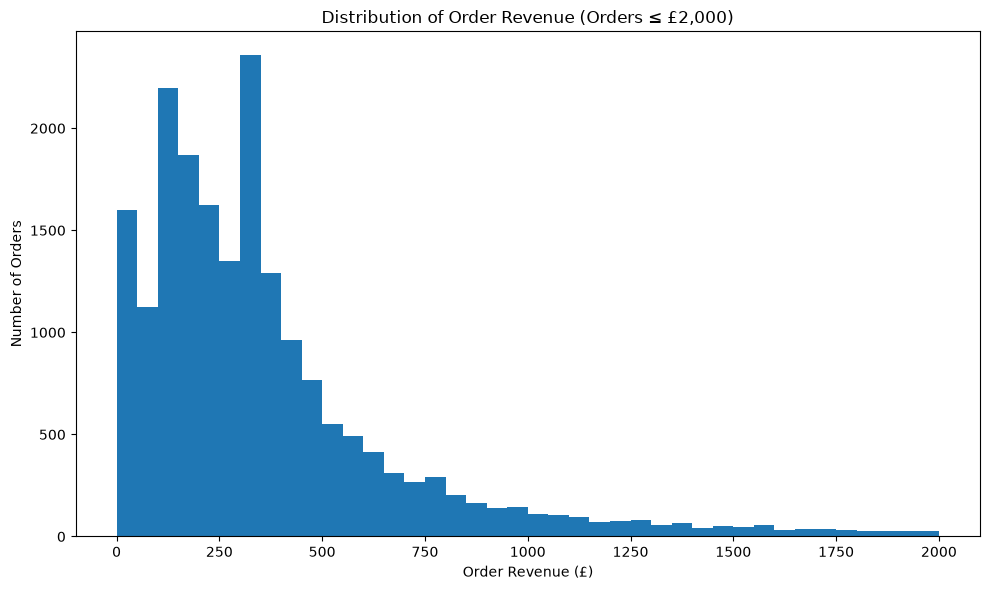

In [35]:
order_revenue_visual = order_summary[
    order_summary["Revenue"] <= 2000
]

plt.figure(figsize=(10, 6))

plt.hist(
    order_revenue_visual["Revenue"],
    bins=40
)

plt.title("Distribution of Order Revenue (Orders ≤ £2,000)")
plt.xlabel("Order Revenue (£)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Order Revenue Distribution

The full order-value distribution is strongly right-skewed because of a small
number of extremely large orders.

To make the typical order pattern easier to visualize, the chart above
focuses on orders with revenue of £2,000 or less. This visualization filter
does not remove or modify any records in the underlying dataset.

Within this range, most orders are concentrated toward the lower revenue
values, with the number of orders gradually decreasing as order value
increases.

The full dataset should still be used for all numerical calculations because
the extreme orders are valid transactions.

In [36]:
order_summary[
    ["Quantity", "LineItems"]
].describe()

,Quantity,LineItems
count,19881.000000,19881.000000
mean,280.094613,26.308687
std,956.727432,47.254383
min,1.000000,1.000000
25%,70.000000,6.000000
50%,151.000000,15.000000
75%,296.000000,29.000000
max,80995.000000,1113.000000


### Order Composition Findings

Orders contain a median of 151 units and 15 line items.

The mean is higher, at 280 units and 26.3 line items per order, because a
small number of unusually large orders increase the average.

The middle 50% of orders contain between 70 and 296 units and between 6 and
29 line items.

The maximum order contains 80,995 units and 1,113 line items. This corresponds
to the previously identified unusual bulk transaction and demonstrates the
effect of extreme orders on the overall distribution.

Overall, the median provides a more representative description of a typical
order than the mean for this dataset.

## 7. Key Business Findings

The exploratory analysis produced several important findings about the
business's sales, products, customers, geographic distribution, and order
behavior.

### Revenue Performance

The cleaned product-sales dataset generated approximately £10.33 million in
revenue across 19,881 transactions.

Revenue increased substantially during the final quarter of the observed
period, with November 2011 recording the highest monthly revenue at
approximately £1.46 million.

December 2011 should not be compared directly with previous months because
the dataset only contains transactions through December 9, 2011.

### Product Performance

Revenue is distributed across a broad range of products. The top 10 products
account for approximately 9.43% of total product revenue.

Several products perform strongly across revenue, quantity, and transaction
frequency, while others generate high revenue through relatively few
transactions.

The `PAPER CRAFT, LITTLE BIRDIE` transaction is a major outlier, generating
approximately £168K from 80,995 units in a single transaction. It was retained
because it is a valid source transaction but should be considered separately
when interpreting product performance.

### Customer Behavior

There are 4,338 customers with an identifiable CustomerID.

Approximately 65.40% of these customers made multiple transactions during the
observed period, while 34.60% made only one transaction.

Repeat customers generated 92.93% of customer-linked revenue, compared with
7.07% from one-time customers.

This shows that repeat purchasing represents a substantial portion of
customer-linked revenue during the observed period. The result should not be
interpreted as a formal retention or churn rate.

### Geographic Distribution

The United Kingdom generated approximately £8.76 million, representing
84.79% of total recorded revenue.

The Netherlands and EIRE were the largest international markets by revenue,
followed by Germany, France, and Australia.

The sales distribution is therefore heavily concentrated in the UK within
this dataset.

### Order Behavior

The average order value was £519.74, while the median was £302.40.

The difference between these measures shows that unusually large orders
increase the average.

The median order contained 151 units across 15 line items, providing a more
representative view of typical order composition.

### Overall Conclusion

The analysis shows a business with strong repeat-customer revenue,
substantial UK concentration, a broad product range, and a highly
right-skewed transaction distribution.

Several unusually large transactions materially affect aggregate metrics.
These transactions were investigated and retained rather than removed
without evidence that they were invalid.

The findings provide a foundation for further analysis of customer value,
product performance, geographic markets, and sales trends.